In [41]:
import numpy as np 
import matplotlib.pyplot as plt 
from analysis import load_data
from scipy.optimize import curve_fit

In [42]:
# Load the data
example1_df = load_data('output-files/EXAMPLE_1_NLMT101.h5')
# Show data for the first few sampled atoms
example1_df.head(5)

,states,x,y,z,vx,vy,vz,phase_shifts,phase_shifts_errors,interference_flag
0,0,-0.001765,0.000007,0.036873,-0.000234,1.808229e-04,-20.247840,-3.576328e+10,0.0,1
1,1,0.001114,0.000561,0.037246,0.000303,4.051653e-04,-20.241266,-3.576328e+10,0.0,1
2,0,0.000356,-0.000189,0.035851,-0.000240,-2.967341e-06,-20.247840,-3.576328e+10,0.0,1
3,0,0.000441,-0.000734,0.035974,-0.000195,-6.517996e-07,-20.247840,-3.576328e+10,0.0,1
4,0,-0.000257,0.000699,0.035770,0.000037,9.153805e-05,-20.247840,-3.576328e+10,0.0,1


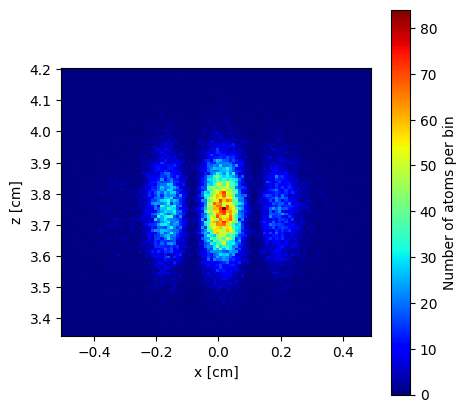

In [43]:
# Plot in the x-z plane
fig,ax = plt.subplots(1,1,figsize=(5,5))

# Select ground-state atoms
ground_df = example1_df[example1_df["states"]==0]

# Generate 2D histogram
h, xedges, zedges = np.histogram2d(ground_df["x"], ground_df["z"],bins=100)

# Get the grid for the imaging plane
X,Z = np.meshgrid(xedges[:-1],zedges[:-1],indexing='ij')

# Plot
p = ax.pcolormesh(X*100,Z*100,h,cmap='jet')
ax.set_xlabel("x [cm]")
ax.set_ylabel("z [cm]")

cmap = fig.colorbar(p)
cmap.set_label("Number of atoms per bin")

ax.set_aspect('equal')

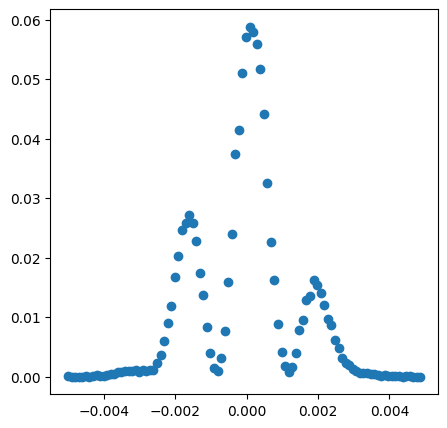

In [ ]:
# Project onto x-axis
h, xedges = np.histogram(ground_df["x"],bins=100,density=True)
dx = xedges[1] - xedges[0]

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.scatter(xedges[:-1],h*dx)

# Extract phase shift
def f(x, A, C, kappa, phi0, sx):
    return A * (1 + C*np.cos(kappa*x + phi0)) * np.exp(-x**2/(2*sx**2))

# initial guess
sx0    = 2e-3
A0     = 0.5 / np.sqrt(2*np.pi*sx0**2)
phi0   = 0
kappa0 = 3140
C0     = 1
p0 = [A0, C0, kappa0, phi0, sx0]

popt,pcov = curve_fit(f, xedges[:-1], h*dx, p0=p0)

# Print results
err = np.sqrt(np.diag(pcov))
param_names = ['A', 'C', 'kappa', 'phi0', 'sx']
for i in range(len(param))
print("A = {:.2e} +/- {:.2e}")